# Multi-Dataset Classification Head on SAM-Med3D

This notebook evaluates whether SAM-Med3D features are discriminative for tumor classification by training a simple classification head on top of the 3D encodings.

**Datasets**: GIST, LIPO, DESMOID, CRLM

**Pipeline**:
1. Preprocess with ROI cropping for all datasets
2. Load SAM-Med3D model using medim
3. Extract embeddings (forced re-extraction)
4. Train classification head for each dataset
5. Compare results across datasets

Before running the full TabPFN/LoCalPFN pipeline, we want to check if the SAM-Med3D features capture useful information for benign vs malignant classification.

In [1]:
import sys
from pathlib import Path
import torch
import numpy as np
import medim

# Add project root to path
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from med3pipe.data.prepare import (
    prepare_for_sam3d_roi_cropped, split_validation, find_default_sam3d_root
)
from med3pipe.sam.core import (
    load_labels_from_sheet, build_sam3d_model, extract_embeddings_train_val,
    default_feature_dirs
)
from med3pipe.training.classification_head import run_classification_head_experiment

print(f"✅ Imports complete")
print(f"   Project root: {PROJECT_ROOT}")
print(f"   Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

✅ Imports complete
   Project root: c:\Users\cahel\Desktop\Med3Tab-PFN
   Device: cpu


## Configuration

In [2]:
# Paths
SAM3D_ROOT = find_default_sam3d_root(PROJECT_ROOT)
CHECKPOINT_PATH = SAM3D_ROOT / "ckpt" / "sam_med3d_turbo.pth"
SHEET_CSV = PROJECT_ROOT / "sheet.csv"

# Configuration
TARGET_SIZE = 128
ROI_MARGIN = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Datasets to process (4 datasets: GIST, LIPO, DESMOID, CRLM)
DATASETS = [
    {
        "name": "GIST",
        "category": "gist",
        "ct_name": "ct_GIST_roi",
        "dataset_root": PROJECT_ROOT / "data" / "gist",
        "dataset_name": "GIST",
        "case_suffix": "_CT",
        "modality": "CT",
        "expected_samples": 246
    },
    {
        "name": "LIPO",
        "category": "lipo",
        "ct_name": "ct_LIPO_roi",
        "dataset_root": PROJECT_ROOT / "data" / "lipo",
        "dataset_name": "Lipo",
        "case_suffix": "_MR",
        "modality": "MR",
        "expected_samples": 115
    },
    {
        "name": "DESMOID",
        "category": "desmoid",
        "ct_name": "ct_DESMOID_roi",
        "dataset_root": PROJECT_ROOT / "data" / "desmoid",
        "dataset_name": "Desmoid",
        "case_suffix": "_MR",
        "modality": "MR",
        "expected_samples": 203
    },
    {
        "name": "CRLM",
        "category": "crlm",
        "ct_name": "ct_CRLM_roi",
        "dataset_root": PROJECT_ROOT / "data" / "crlm",
        "dataset_name": "CRLM",
        "case_suffix": "_CT",
        "modality": "CT",
        "expected_samples": 77
    }
]

# Training configuration
FREEZE_ENCODER = True  # Set to False to fine-tune encoder
NUM_EPOCHS = 10
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3
DROPOUT = 0.2
IMG_SIZE = 128

# Split configuration
SPLIT_RATIO = 0.8
SEED = 2025

# Output
OUTPUT_BASE_DIR = PROJECT_ROOT / "results" / "classification_head"

print(f"Configuration:")
print(f"  SAM-Med3D root: {SAM3D_ROOT}")
print(f"  Checkpoint: {CHECKPOINT_PATH}")
print(f"  Device: {DEVICE}")
print(f"  Datasets to process: {[d['name'] for d in DATASETS]}")
print(f"  Total expected samples: {sum(d['expected_samples'] for d in DATASETS)}")
print(f"  Freeze encoder: {FREEZE_ENCODER}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Output base: {OUTPUT_BASE_DIR}")

Configuration:
  SAM-Med3D root: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main
  Checkpoint: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth
  Device: cpu
  Datasets to process: ['GIST', 'LIPO', 'DESMOID', 'CRLM']
  Total expected samples: 641
  Freeze encoder: True
  Epochs: 10
  Output base: c:\Users\cahel\Desktop\Med3Tab-PFN\results\classification_head


## Step 1: Prepare All Datasets with ROI Cropping

In [3]:
# Process each dataset with ROI cropping
all_results = {}

for dataset_config in DATASETS:
    print(f"\n{'='*70}")
    print(f"PREPARING DATASET: {dataset_config['name']}")
    print(f"{'='*70}\n")
    
    # Prepare ROI-cropped data
    n_prepared, paths = prepare_for_sam3d_roi_cropped(
        dataset_root=dataset_config['dataset_root'],
        sam3d_root=SAM3D_ROOT,
        category=dataset_config['category'],
        ct_name=dataset_config['ct_name'],
        target_size=TARGET_SIZE,
        margin=ROI_MARGIN,
        max_cases=None  # Process all cases
    )
    
    print(f"✅ Prepared {n_prepared} ROI-cropped cases for {dataset_config['name']}")
    print(f"   Output: {paths.train_root}")
    
    # Store paths for later use
    dataset_config['paths'] = paths

print(f"\n{'='*70}")
print("ALL DATASETS PREPARED")
print(f"{'='*70}")


PREPARING DATASET: GIST

Prepared 25 ROI-cropped cases ...
Prepared 25 ROI-cropped cases ...
Prepared 50 ROI-cropped cases ...
Prepared 50 ROI-cropped cases ...
Prepared 75 ROI-cropped cases ...
Prepared 75 ROI-cropped cases ...
Prepared 100 ROI-cropped cases ...
Prepared 100 ROI-cropped cases ...
Prepared 125 ROI-cropped cases ...
Prepared 125 ROI-cropped cases ...
Prepared 150 ROI-cropped cases ...
Prepared 150 ROI-cropped cases ...
Prepared 175 ROI-cropped cases ...
Prepared 175 ROI-cropped cases ...
Prepared 200 ROI-cropped cases ...
Prepared 200 ROI-cropped cases ...
Prepared 225 ROI-cropped cases ...
Prepared 225 ROI-cropped cases ...
Done. Prepared 246 ROI-cropped cases to C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\train\gist\ct_GIST_roi
✅ Prepared 246 ROI-cropped cases for GIST
   Output: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\train\gist\ct_GIST_roi

PREPARING DATASET: LIPO

Done. Prepared 246 ROI-cropped cases to C:\Us

## Step 2: Load SAM-Med3D Model using medim

In [4]:
# Check GPU availability first
print(f"🔍 Checking GPU availability...")
print(f"   CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print(f"   ⚠️  Running on CPU - training will be VERY slow!")
    print(f"   Consider enabling GPU for 10-50x speedup")

# Check if checkpoint exists
if not CHECKPOINT_PATH.exists():
    print(f"\n⚠️  Checkpoint not found: {CHECKPOINT_PATH}")
    print("   Download from: https://huggingface.co/blueyo0/SAM-Med3D/resolve/main/sam_med3d_turbo.pth")
else:
    size_mb = CHECKPOINT_PATH.stat().st_size / (1024*1024)
    print(f"\n✅ Checkpoint found: {CHECKPOINT_PATH} ({size_mb:.1f} MB)")

# Load SAM-Med3D model using medim
print(f"\n📦 Loading SAM-Med3D model with medim on {DEVICE}...")
sam_model = build_sam3d_model(
    sam3d_root=SAM3D_ROOT,
    model_type="vit_b_ori",
    checkpoint=CHECKPOINT_PATH,
    device=DEVICE,
    eval_mode=True,
    use_medim=True
)

print(f"✅ SAM-Med3D model loaded successfully!")
print(f"   Model device: {next(sam_model.parameters()).device}")
print(f"   Model dtype: {next(sam_model.parameters()).dtype}")

🔍 Checking GPU availability...
   CUDA available: False
   ⚠️  Running on CPU - training will be VERY slow!
   Consider enabling GPU for 10-50x speedup

✅ Checkpoint found: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth (383.5 MB)

📦 Loading SAM-Med3D model with medim on cpu...
Loading SAM-Med3D model via medim from: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth
creating model SAM-Med3D
try to load pretrained weights from C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth
✅ SAM-Med3D model loaded successfully via medim!
✅ SAM-Med3D model loaded successfully!
   Model device: cpu
   Model dtype: torch.float32
✅ SAM-Med3D model loaded successfully via medim!
✅ SAM-Med3D model loaded successfully!
   Model device: cpu
   Model dtype: torch.float32


## Step 3: Extract Embeddings (Forced Re-extraction)

In [5]:
# Extract embeddings for all datasets - FORCED RE-EXTRACTION
for dataset_config in DATASETS:
    print(f"\n{'='*70}")
    print(f"EXTRACTING EMBEDDINGS: {dataset_config['name']}")
    print(f"{'='*70}\n")
    
    paths = dataset_config['paths']
    
    # Get or create feature directories
    feature_dirs = default_feature_dirs(
        sam3d_root=SAM3D_ROOT,
        category=dataset_config['category'],
        ct_name=dataset_config['ct_name']
    )
    
    # Extract embeddings with skip_existing=False to force re-extraction
    print(f"Extracting embeddings from {paths.images_tr}...")
    feature_dirs = extract_embeddings_train_val(
        paths=paths,
        model=sam_model,
        sam3d_root=SAM3D_ROOT,
        img_size=TARGET_SIZE,
        feature_dirs=feature_dirs,
        device=DEVICE,
        skip_existing=False  # FORCE RE-EXTRACTION
    )
    
    print(f"✅ Extracted embeddings for {dataset_config['name']}")
    print(f"   Train features: {feature_dirs.train_dir}")
    
    # Store feature dirs for later use
    dataset_config['feature_dirs'] = feature_dirs

print(f"\n{'='*70}")
print("ALL EMBEDDINGS EXTRACTED")
print(f"{'='*70}")


EXTRACTING EMBEDDINGS: GIST

Extracting embeddings from C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\train\gist\ct_GIST_roi\imagesTr...
To extract: 246 from C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\train\gist\ct_GIST_roi\imagesTr
Extracted 25 embeddings ...
Extracted 25 embeddings ...
Extracted 50 embeddings ...
Extracted 50 embeddings ...
Extracted 75 embeddings ...
Extracted 75 embeddings ...
Extracted 100 embeddings ...
Extracted 100 embeddings ...
Extracted 125 embeddings ...
Extracted 125 embeddings ...
Extracted 150 embeddings ...
Extracted 150 embeddings ...
Extracted 175 embeddings ...
Extracted 175 embeddings ...
Extracted 200 embeddings ...
Extracted 200 embeddings ...
Extracted 225 embeddings ...
Extracted 225 embeddings ...
Done extracting to: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\features\gist\ct_GIST_roi_train
To extract: 50 from C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-ma

## Step 4: Load Labels and Run Classification Head for Each Dataset

In [6]:
NUM_EPOCHS = 10


# Train classification head for each dataset
for dataset_config in DATASETS:
    print(f"\n{'='*70}")
    print(f"TRAINING CLASSIFICATION HEAD: {dataset_config['name']}")
    print(f"{'='*70}\n")
    
    paths = dataset_config['paths']
    
    # Create validation split
    split_validation(
        paths,
        split_ratio=SPLIT_RATIO,
        seed=SEED,
        copy=True,
    )
    print("✓ Validation split created")
    
    # Load labels
    df, lab_map = load_labels_from_sheet(
        sheet_csv=SHEET_CSV,
        dataset_name=dataset_config['dataset_name'],
        subject_col="Subject",
        label_col="Diagnosis_binary",
        case_suffix=dataset_config['case_suffix'],
    )
    
    print(f"✓ Loaded {len(lab_map)} labels")
    print(f"  Benign: {(df['label'] == 0).sum()}")
    print(f"  Malignant: {(df['label'] == 1).sum()}")
    
    # Set output directory for this dataset
    output_dir = OUTPUT_BASE_DIR / dataset_config['name'].lower()
    
    # Run classification head experiment with medim
    results = run_classification_head_experiment(
        paths=paths,
        lab_map=lab_map,
        sam3d_root=SAM3D_ROOT,
        model_type="vit_b_ori",
        checkpoint=CHECKPOINT_PATH,
        img_size=IMG_SIZE,
        device=DEVICE,
        freeze_encoder=FREEZE_ENCODER,
        num_epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        dropout=DROPOUT,
        num_workers=2,
        output_dir=output_dir,
        use_medim=True,  # Use medim for model loading
    )
    
    # Store results
    dataset_config['results'] = results
    
    print(f"\n✅ Training complete for {dataset_config['name']}")
    print(f"   Final Epoch Accuracy: {results['final_metrics'].accuracy:.4f}")
    print(f"   Final Epoch AUC: {results['final_metrics'].auc:.4f}")

print(f"\n{'='*70}")
print("ALL DATASETS TRAINED")
print(f"{'='*70}")


TRAINING CLASSIFICATION HEAD: GIST

Validation set copied to: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\validation\gist\ct_GIST_roi | Train: 196 | Val: 50
✓ Validation split created
✓ Loaded 246 labels
  Benign: 121
  Malignant: 125

SAM-Med3D Classification Head Experiment
Device: cpu
Model: vit_b_ori
Encoder frozen: True
Image size: 128
Batch size: 8
Epochs: 10
Learning rate: 0.0001

[1/4] Building SAM-Med3D model...
Loading SAM-Med3D model via medim from: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth
creating model SAM-Med3D
try to load pretrained weights from C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth
Validation set copied to: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\validation\gist\ct_GIST_roi | Train: 196 | Val: 50
✓ Validation split created
✓ Loaded 246 labels
  Benign: 121
  Malignant: 125

SAM-Med3D Classification Head Experiment


c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Epoch [1/10] - Time: 1096.77s
Train Loss: 0.6914 | Train Acc: 0.5081
Val Loss:   0.6869 | Val Acc:   0.5600
Val AUC:    0.5617
LR:         0.000098
✓ Best model saved (AUC: 0.5617)

✓ Best model saved (AUC: 0.5617)

  Batch [10/31] Loss: 0.7364
  Batch [10/31] Loss: 0.7364
  Batch [20/31] Loss: 0.7147
  Batch [20/31] Loss: 0.7147
  Batch [30/31] Loss: 0.7120
  Batch [30/31] Loss: 0.7120


c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Epoch [2/10] - Time: 1060.71s
Train Loss: 0.6891 | Train Acc: 0.5122
Val Loss:   0.6863 | Val Acc:   0.5600
Val AUC:    0.5779
LR:         0.000091
✓ Best model saved (AUC: 0.5779)

✓ Best model saved (AUC: 0.5779)

  Batch [10/31] Loss: 0.6614
  Batch [10/31] Loss: 0.6614
  Batch [20/31] Loss: 0.7075
  Batch [20/31] Loss: 0.7075
  Batch [30/31] Loss: 0.6691
  Batch [30/31] Loss: 0.6691


...


Epoch [9/10] - Time: 844.35s
Train Loss: 0.6492 | Train Acc: 0.6453
Val Loss:   0.6575 | Val Acc:   0.7317
Val AUC:    0.6545
LR:         0.000003

  Batch [8/26] Loss: 0.6986
  Batch [8/26] Loss: 0.6986
  Batch [16/26] Loss: 0.6449
  Batch [16/26] Loss: 0.6449
  Batch [24/26] Loss: 0.6717
  Batch [24/26] Loss: 0.6717


c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Epoch [10/10] - Time: 843.44s
Train Loss: 0.6471 | Train Acc: 0.6453
Val Loss:   0.6575 | Val Acc:   0.7317
Val AUC:    0.6576
LR:         0.000001


Training Complete!
Best Epoch: 4 | Best Val AUC: 0.6667
Using final epoch model for evaluation


c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Final Validation Metrics
Accuracy: 0.7317
AUC:      0.6576

Confusion Matrix:
[[30  0]
 [11  0]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.73      1.00      0.85        30
   Malignant       0.00      0.00      0.00        11

    accuracy                           0.73        41
   macro avg       0.37      0.50      0.42        41
weighted avg       0.54      0.73      0.62        41


✓ Results saved to c:\Users\cahel\Desktop\Med3Tab-PFN\results\classification_head\desmoid

✅ Training complete for DESMOID
   Final Epoch Accuracy: 0.7317
   Final Epoch AUC: 0.6576

TRAINING CLASSIFICATION HEAD: CRLM

Validation set copied to: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\data\validation\crlm\ct_CRLM_roi | Train: 61 | Val: 16
✓ Validation split created
✓ Loaded 77 labels
  Benign: 40
  Malignant: 37

SAM-Med3D Classification Head Experiment
Device: cpu
Model: vit_b_ori
Encoder frozen: True
Image size: 128
Ba

## Step 5: Results Summary Across All Datasets


CROSS-DATASET SUMMARY (Final Epoch Performance)
Dataset  Samples  Total Epochs  Final Accuracy  Final AUC
   GIST      246            10        0.560000   0.618506
   LIPO      115            10        0.608696   0.591667
DESMOID      203            10        0.731707   0.657576
   CRLM       77            10        0.625000   0.683333

Note: All metrics are from the FINAL epoch, not the best performing epoch.


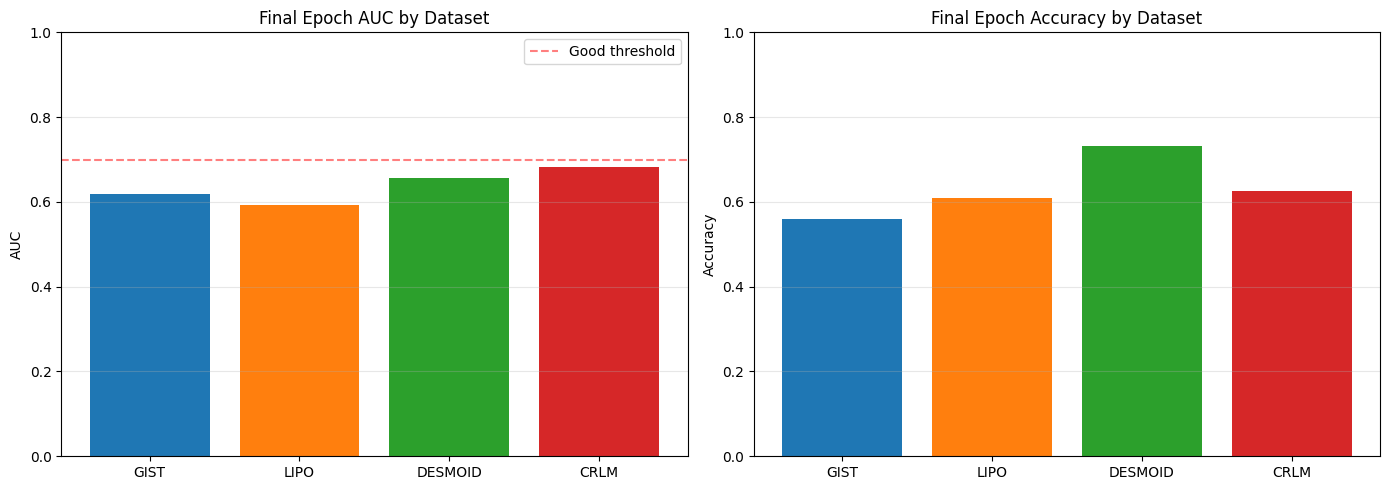


✓ Comparison plot saved to c:\Users\cahel\Desktop\Med3Tab-PFN\results\classification_head\cross_dataset_comparison.png


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Create summary table - using FINAL EPOCH metrics
summary_data = []
for dataset_config in DATASETS:
    results = dataset_config['results']
    metrics = results['final_metrics']
    summary_data.append({
        'Dataset': dataset_config['name'],
        'Samples': dataset_config['expected_samples'],
        'Total Epochs': NUM_EPOCHS,
        'Final Accuracy': metrics.accuracy,
        'Final AUC': metrics.auc,
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("CROSS-DATASET SUMMARY (Final Epoch Performance)")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)
print("\nNote: All metrics are from the FINAL epoch, not the best performing epoch.")

# Bar plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC comparison
axes[0].bar(summary_df['Dataset'], summary_df['Final AUC'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_ylabel('AUC')
axes[0].set_title('Final Epoch AUC by Dataset')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=0.7, color='r', linestyle='--', alpha=0.5, label='Good threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Accuracy comparison
axes[1].bar(summary_df['Dataset'], summary_df['Final Accuracy'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Final Epoch Accuracy by Dataset')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_BASE_DIR / 'cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Comparison plot saved to {OUTPUT_BASE_DIR / 'cross_dataset_comparison.png'}")

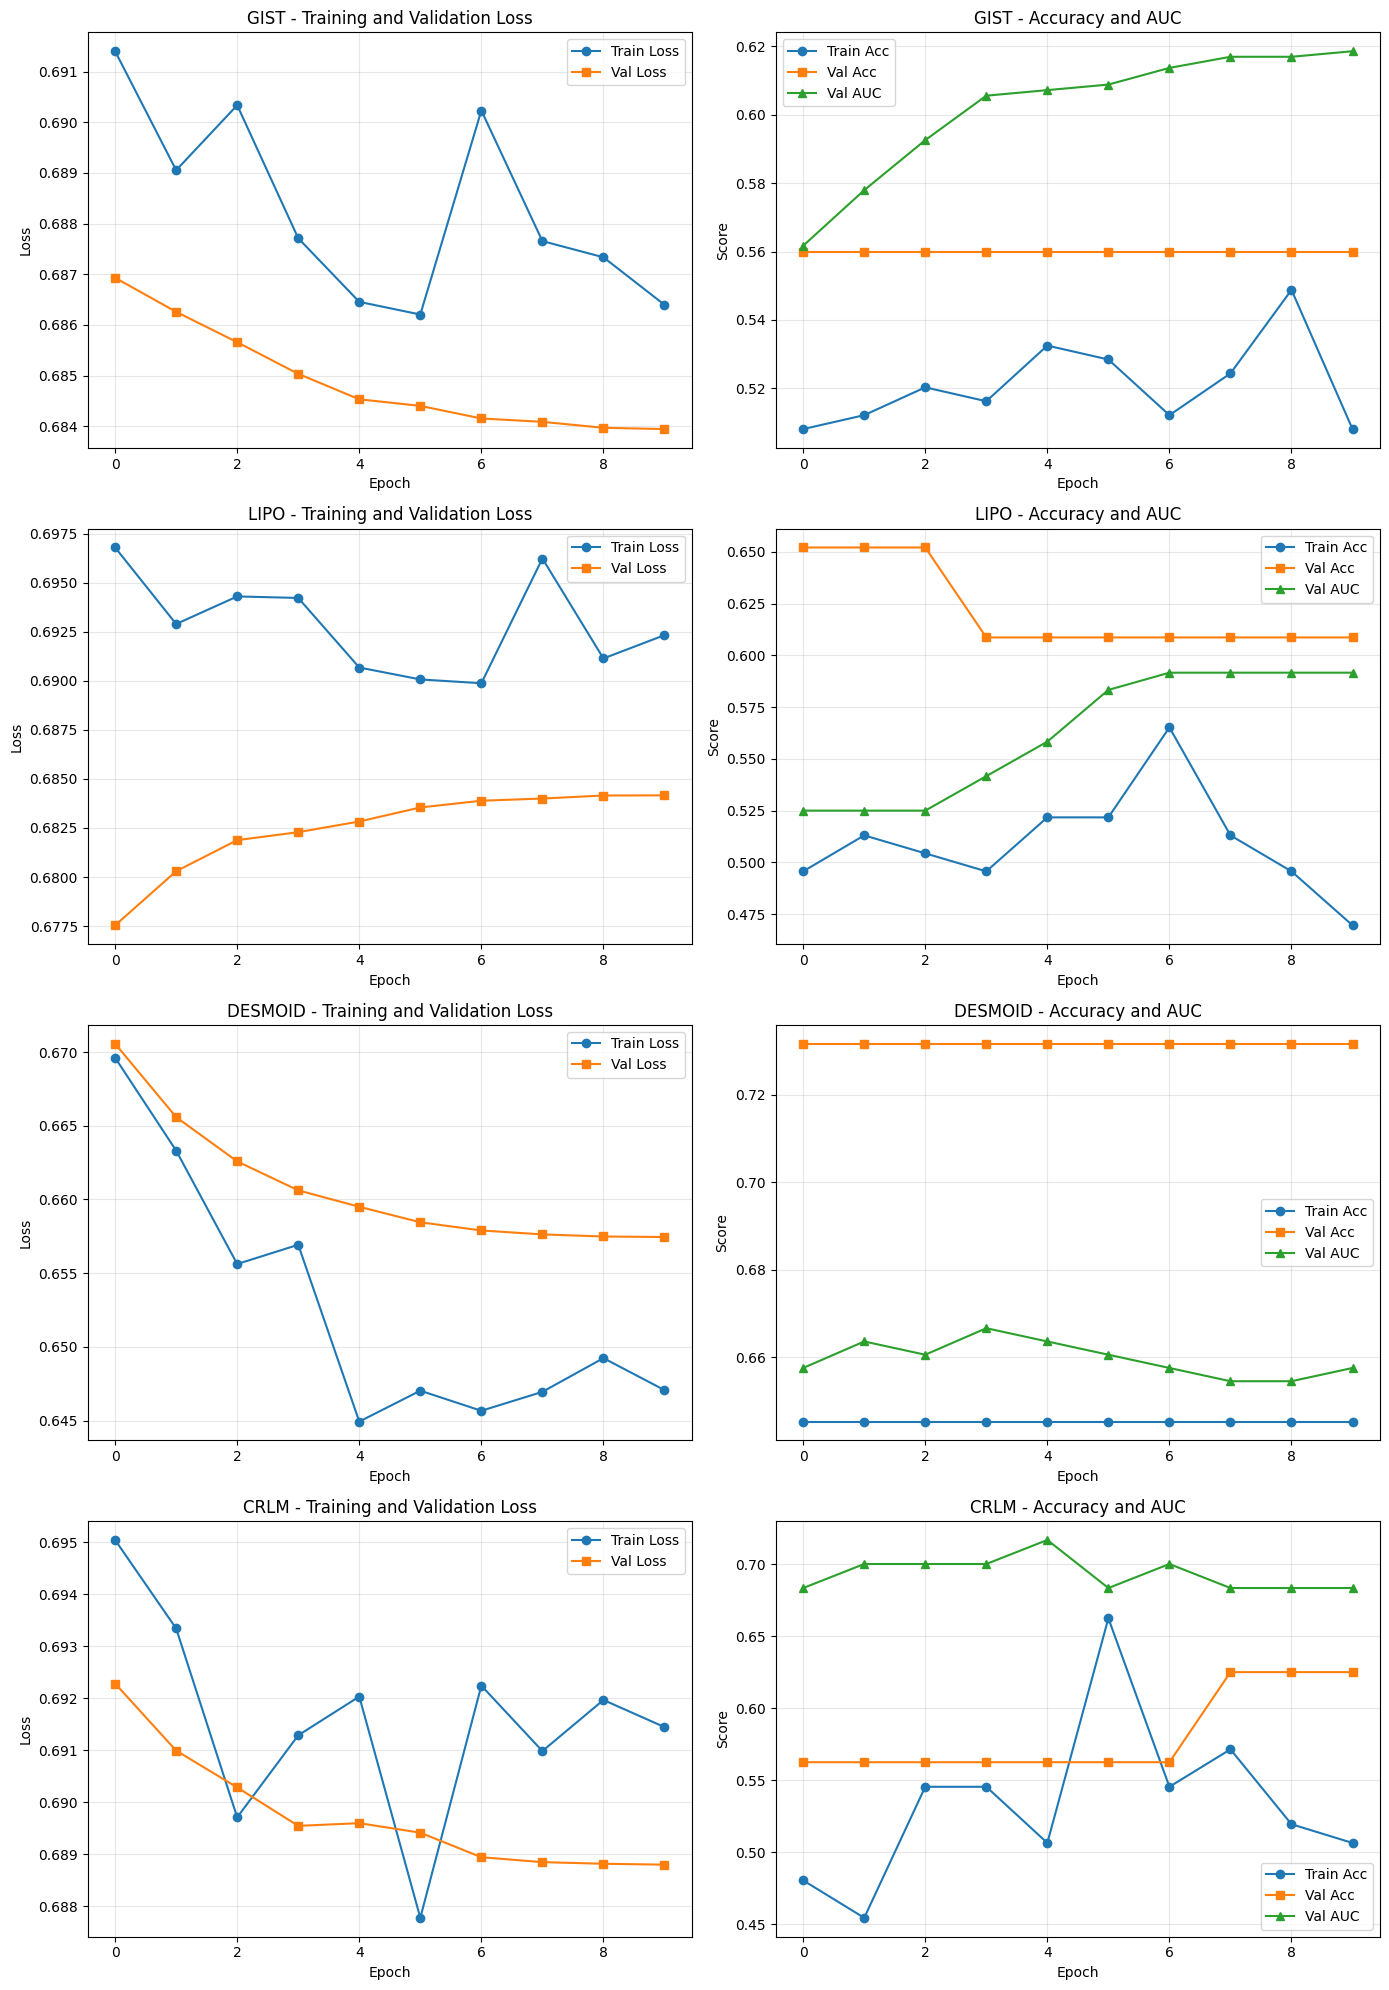


✓ Training curves saved to c:\Users\cahel\Desktop\Med3Tab-PFN\results\classification_head\all_training_curves.png


In [8]:
# Plot training curves for each dataset
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(14, 5 * len(DATASETS)))

if len(DATASETS) == 1:
    axes = axes.reshape(1, -1)

for idx, dataset_config in enumerate(DATASETS):
    results = dataset_config['results']
    history = results['history']
    
    # Loss
    axes[idx, 0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[idx, 0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].set_title(f'{dataset_config["name"]} - Training and Validation Loss')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Accuracy and AUC
    axes[idx, 1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[idx, 1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[idx, 1].plot(history['val_auc'], label='Val AUC', marker='^')
    axes[idx, 1].set_xlabel('Epoch')
    axes[idx, 1].set_ylabel('Score')
    axes[idx, 1].set_title(f'{dataset_config["name"]} - Accuracy and AUC')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_BASE_DIR / 'all_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Training curves saved to {OUTPUT_BASE_DIR / 'all_training_curves.png'}")

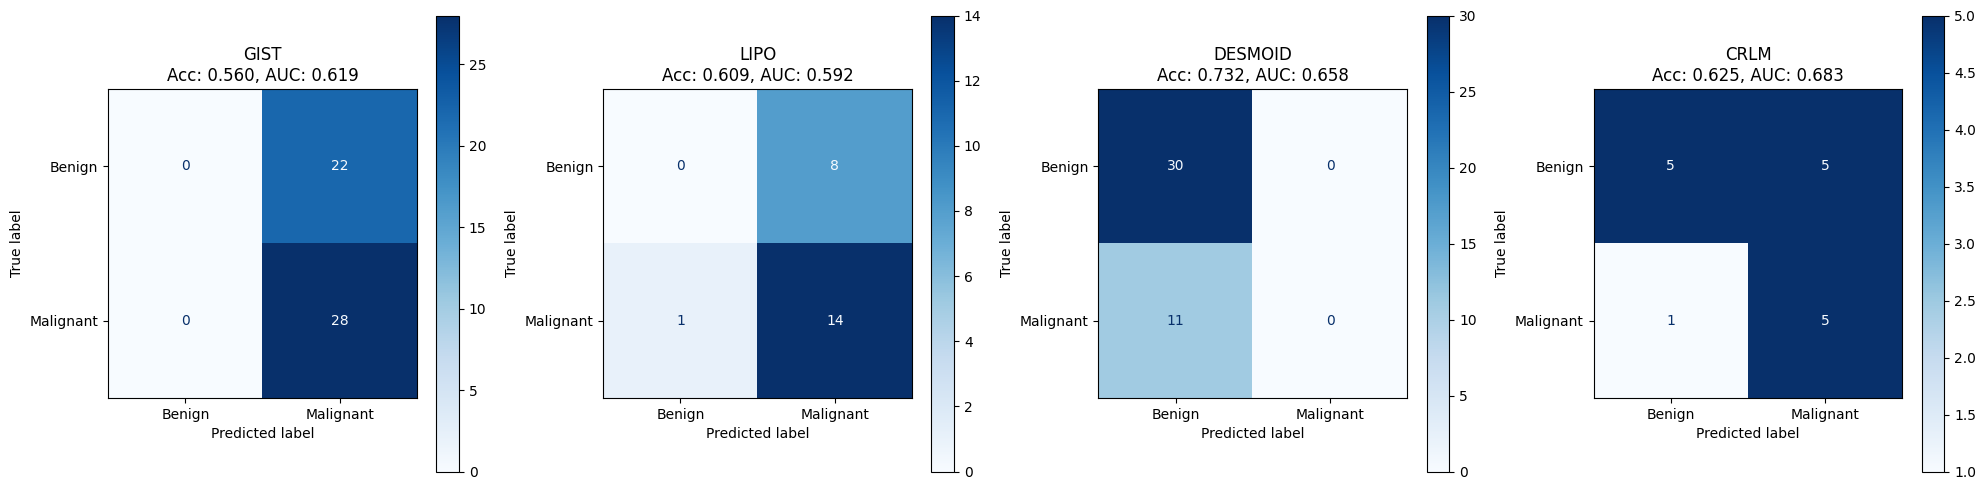


✓ Confusion matrices saved to c:\Users\cahel\Desktop\Med3Tab-PFN\results\classification_head\all_confusion_matrices.png


In [9]:
# Plot confusion matrices for all datasets
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(DATASETS), figsize=(5 * len(DATASETS), 5))

if len(DATASETS) == 1:
    axes = [axes]

for idx, dataset_config in enumerate(DATASETS):
    metrics = dataset_config['results']['final_metrics']
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=metrics.confusion_matrix,
        display_labels=["Benign", "Malignant"]
    )
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{dataset_config["name"]}\nAcc: {metrics.accuracy:.3f}, AUC: {metrics.auc:.3f}')

plt.tight_layout()
plt.savefig(OUTPUT_BASE_DIR / 'all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Confusion matrices saved to {OUTPUT_BASE_DIR / 'all_confusion_matrices.png'}")

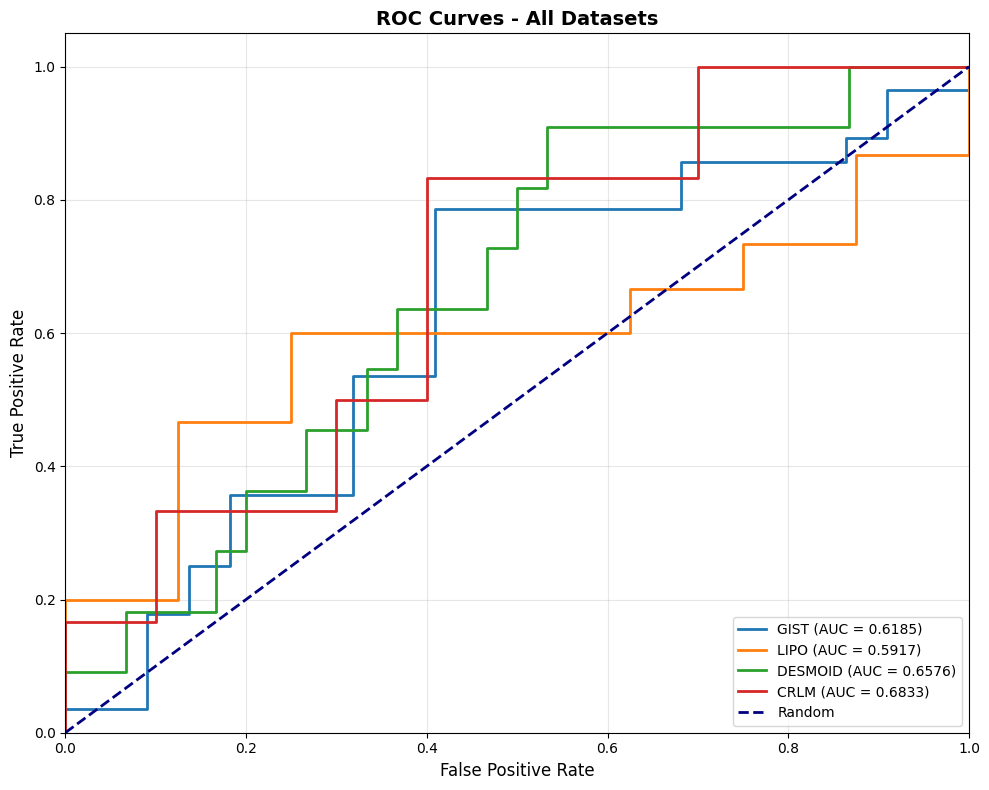


✓ ROC curves saved to c:\Users\cahel\Desktop\Med3Tab-PFN\results\classification_head\all_roc_curves.png


In [10]:
# Plot ROC curves for all datasets
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, dataset_config in enumerate(DATASETS):
    metrics = dataset_config['results']['final_metrics']
    fpr, tpr, _ = roc_curve(metrics.targets, metrics.probabilities)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, color=colors[idx], lw=2, 
            label=f'{dataset_config["name"]} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - All Datasets', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_BASE_DIR / 'all_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ ROC curves saved to {OUTPUT_BASE_DIR / 'all_roc_curves.png'}")

## Interpretation

**Evaluation Criteria:**

- **Good Features** (AUC > 0.7): SAM-Med3D learned meaningful representations
  - ✅ Proceed with TabPFN/LoCalPFN pipeline
  - Consider fine-tuning for better performance

- **Moderate Features** (0.6 < AUC < 0.7): Features have some signal but limited
  - TabPFN/LoCalPFN might help extract more from features
  - Consider fine-tuning SAM-Med3D on your data

- **Poor Features** (AUC < 0.6): May not be suitable for this task
  - Check data quality and labels
  - Try different pretrained weights or architectures
  - Consider alternative feature extraction strategies

**Cross-Dataset Analysis:**

Compare performance across GIST, LIPO, DESMOID, and CRLM to understand:
- Which tumor types have more discriminative features
- Dataset-specific challenges
- Potential for transfer learning or multi-dataset training